# Step 6: Robustness Audit

Does the model hold up when inputs are noisy, incomplete or slightly wrong (survey section 4.4)?

- **Performance Degradation** PD = M_original - M_perturbed
- **Relative degradation** RPD = PD / M_original, with M = accuracy (F1 is also reported)

Three controlled perturbations, each at three levels, averaged over 3 random repeats:

| Perturbation | What changes |
|---|---|
| noise | Gaussian noise on age and weekly hours, as a fraction of each column's spread |
| missing | a fraction of input values set to missing |
| swap | a fraction of categorical values replaced by another applicant's value |

The risk uses the middle level of each. Threshold: relative accuracy loss of 5% (a documented default).

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.model import load_processed, build_dtypes, apply_dtypes

PROCESSED_DIR = os.path.abspath("../data/processed")
RESULTS_DIR = os.path.abspath("../results")
from src.audit.robustness import audit_robustness, DEFAULT_THRESHOLDS
X_train, X_test, y_train, y_test, g_train, g_test = load_processed(PROCESSED_DIR)
dtypes = build_dtypes(X_train, X_test)
Xte = apply_dtypes(X_test, dtypes)
yte = y_test.to_numpy()

model = XGBClassifier()
model.load_model(os.path.join(RESULTS_DIR, "baseline_xgb.json"))
p = model.predict_proba(Xte)[:, 1]
print("Test rows:", Xte.shape)


Test rows: (38642, 10)


## 1. Run the audit (this refits no model; it only re-predicts on perturbed copies)

In [2]:
result = audit_robustness(model, Xte, y_true=yte)
print(result.summary())

Robustness: risk 0.376 (pass)
  - noise (0.2): accuracy falls 1.1% relative; 5.3% of decisions change.
  - missing (0.1): accuracy falls 3.8% relative; 8.5% of decisions change.
  - swap (0.05): accuracy falls 1.2% relative; 2.9% of decisions change.


In [3]:
result.details["grid"].round(4)

,perturbation,level,accuracy,f1,pd_accuracy,rpd_accuracy,flip_rate
0,noise,0.10,0.8114,0.8021,0.0041,0.0051,0.0318
1,noise,0.20,0.8064,0.7966,0.0092,0.0113,0.0527
2,noise,0.50,0.7841,0.7678,0.0314,0.0385,0.1045
3,missing,0.05,0.8016,0.8006,0.0139,0.0171,0.0441
4,missing,0.10,0.7849,0.7908,0.0307,0.0376,0.0846
5,missing,0.20,0.7445,0.7686,0.0710,0.0871,0.1658
6,swap,0.02,0.8115,0.8041,0.0040,0.0049,0.0119
7,swap,0.05,0.8062,0.7982,0.0094,0.0115,0.0291
8,swap,0.10,0.7959,0.7867,0.0196,0.0241,0.0556


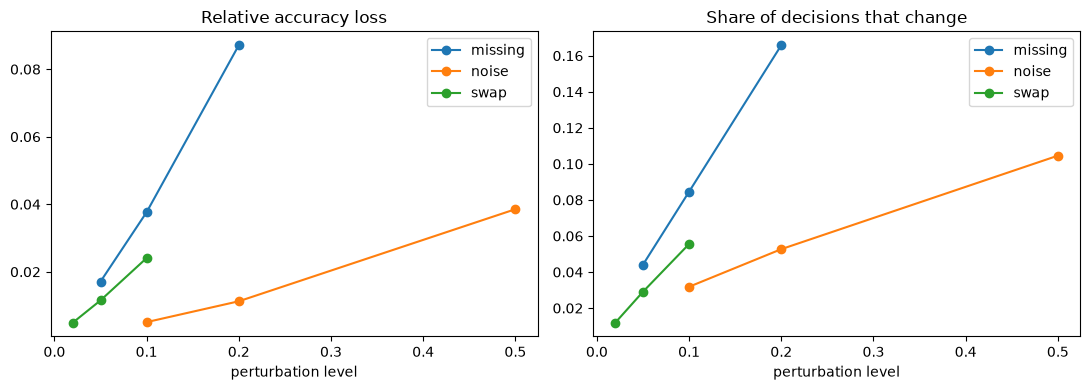

In [4]:
g = result.details["grid"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for kind, d in g.groupby("perturbation"):
    axes[0].plot(d["level"], d["rpd_accuracy"], "o-", label=kind)
    axes[1].plot(d["level"], d["flip_rate"], "o-", label=kind)
axes[0].set_title("Relative accuracy loss"); axes[1].set_title("Share of decisions that change")
for a in axes:
    a.set_xlabel("perturbation level"); a.legend()
plt.tight_layout(); plt.show()

## 2. Sensitivity to the threshold

In [5]:
rows = []
for scale in (0.5, 1.0, 1.5):
    thr = {k: v * scale for k, v in DEFAULT_THRESHOLDS.items()}
    r = audit_robustness(model, Xte, y_true=yte, thresholds=thr)
    rows.append({"threshold_scale": scale, "risk": round(r.risk, 3), "status": r.status})
pd.DataFrame(rows)

,threshold_scale,risk,status
0,0.5,0.753,fail
1,1.0,0.376,pass
2,1.5,0.251,pass


In [6]:
from src.audit.common import save_result
save_result(result, os.path.join(RESULTS_DIR, "robustness_result.json"))
print("Saved")

Saved


## Summary and next step

- Measured accuracy loss and decision changes under noise, missing values and categorical swaps.
- Saved `results/robustness_result.json`.

**Next:** notebook 07, the Human-oversight module (simulated in Phase 1).